# RQ2 follow-up — Prompting strategies on Llama-3.1-8B-Instruct

This notebook compares **all prompting strategies on a single model**,
`llama3.1-8b-instruct-q4_K_M`: the five strategies from Liscio et al. (2025)
(`vanilla`, `simple`, `cot`, `oracle`, `class`) plus our four proposed few-shot
strategies (`simple_fewshot`, `cot_fewshot`, `simple_fewshot_mft`, `cot_fewshot_mft`).

Two questions, mirroring the main RQ2 notebook:

- **RQ2a (8B)** — Does the 8B model shift the political stance of the articles it
  summarizes, and does it show the same *regression-to-center* pattern as the three
  larger models?
- **RQ2b (8B)** — Do any strategies (in particular the proposed few-shot ones)
  produce a **smaller** stance shift than the plain `vanilla` baseline?

**Differences from the main notebook.** The 8B summaries were generated **once per
(article, method)** — there are no seed replicates, so there is no seed-averaging
step: each (article, method) cell is a single observation. This does not affect the
paired Wilcoxon tests (pairing is by article, not by seed), but per-cell means are
noisier. The method grid is also incomplete (75–153 articles per method, pairing
with `vanilla`); paired tests use only the articles present in **both** conditions,
so *n* varies per contrast.

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

# --- Paths ---
REPO_ROOT   = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SHIFTS_PATH = REPO_ROOT / 'political_shift' / 'data' / 'shifts.parquet'

# --- Constants ---
MODEL_ID      = 'llama3.1-8b-instruct-q4_K_M'
BASELINES     = ['vanilla', 'simple', 'cot', 'oracle', 'class']
FEWSHOT       = ['simple_fewshot', 'cot_fewshot', 'simple_fewshot_mft', 'cot_fewshot_mft']
METHOD_ORDER  = BASELINES + FEWSHOT
LEANING_ORDER = ['center', 'left', 'right']
LEANING_COLORS = {'left': '#3b76d1', 'center': '#7e7e7e', 'right': '#c83e3e'}

shifts = pd.read_parquet(SHIFTS_PATH)
d8 = shifts[shifts['model'] == MODEL_ID].copy()
d8['method']  = pd.Categorical(d8['method'],  categories=METHOD_ORDER)
d8['leaning'] = pd.Categorical(d8['leaning'], categories=LEANING_ORDER)

# Single run per cell: assert one row per (article, method).
assert d8.groupby(['article_id', 'method'], observed=True).size().max() == 1

print(f'{len(d8):,} rows  ({d8.method.nunique()} methods x '
      f'{d8.article_id.nunique()} articles, single seed)')

1,082 rows  (9 methods x 180 articles, single seed)


### Coverage

The grid is incomplete: not every (article, method) cell was generated. The table
below shows the number of articles per method and how many of them can be paired
with `vanilla` (the *n* of each RQ2b contrast). `class` has very few articles, so
its test is reported but underpowered.

In [2]:
van_arts = set(d8.loc[d8['method'] == 'vanilla', 'article_id'])
coverage = (d8.groupby('method', observed=True)['article_id']
              .agg(n_articles='nunique',
                   paired_with_vanilla=lambda s: len(set(s) & van_arts))
              .reindex(METHOD_ORDER))
coverage

,n_articles,paired_with_vanilla
method,,
vanilla,159,159
simple,143,126
cot,82,75
oracle,93,78
class,21,19
simple_fewshot,167,148
cot_fewshot,113,101
simple_fewshot_mft,173,153
cot_fewshot_mft,131,116


## RQ2a (8B) — Does the 8B model shift the political stance?

Same test as the main notebook: for each (leaning, outcome) an intercept-only linear
mixed-effects model with a random intercept per article,

```
shift ~ 1,  (1 | article_id)
```

The random intercept absorbs the repetition of each article across methods. The
intercept is the mean shift for that leaning; its p-value tests whether it differs
from zero.

In [3]:
rows = []
for outcome in ['direction_shift', 'polarization_shift']:
    for lean in LEANING_ORDER:
        sub = d8[d8['leaning'] == lean]
        res = smf.mixedlm(f'{outcome} ~ 1', sub, groups=sub['article_id']).fit(reml=True)
        p = res.pvalues['Intercept']
        rows.append({
            'outcome': outcome.replace('_shift', ''),
            'leaning': lean,
            'mean_shift': round(res.params['Intercept'], 3),
            'p': round(p, 4),
            'sig (p<.05)': '*' if p < 0.05 else '',
        })

rq2a = pd.DataFrame(rows)
rq2a

,outcome,leaning,mean_shift,p,sig (p<.05)
0,direction,center,0.132,0.0409,*
1,direction,left,0.346,0.0000,*
2,direction,right,-0.026,0.6510,
3,polarization,center,0.194,0.0000,*
4,polarization,left,-0.109,0.0000,*
5,polarization,right,-0.078,0.0025,*


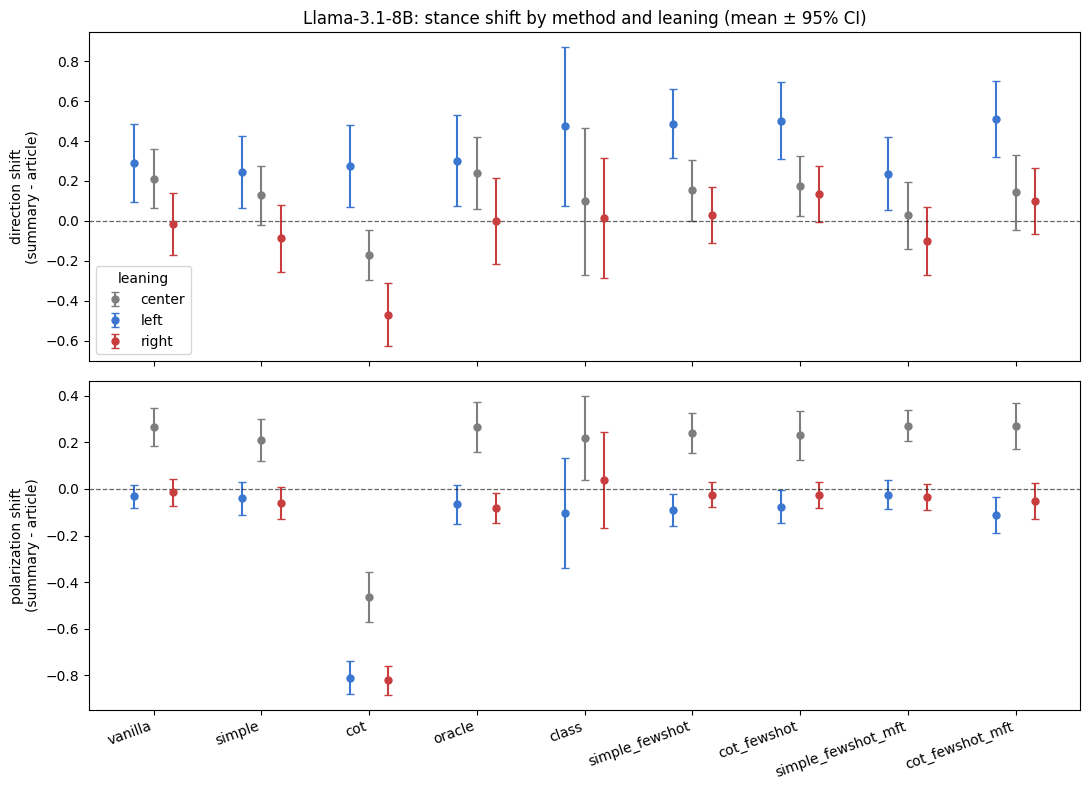

In [4]:
# Visual: mean shift +/- 95% CI by method and leaning, both outcomes.
def mean_ci(v):
    v = np.asarray(v, float)
    return v.mean(), 1.96 * v.std(ddof=1) / np.sqrt(len(v))

JITTER = {'left': -0.18, 'center': 0.0, 'right': 0.18}
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for ax, outcome in zip(axes, ['direction_shift', 'polarization_shift']):
    for lean in LEANING_ORDER:
        xs, ys, es = [], [], []
        for k, method in enumerate(METHOD_ORDER):
            sub = d8[(d8['leaning'] == lean) & (d8['method'] == method)][outcome]
            if len(sub) < 2:
                continue
            mu, half = mean_ci(sub)
            xs.append(k + JITTER[lean]); ys.append(mu); es.append(half)
        ax.errorbar(xs, ys, yerr=es, fmt='o', ms=5, capsize=3,
                    color=LEANING_COLORS[lean],
                    label=lean if outcome == 'direction_shift' else None)
    ax.axhline(0, color='black', lw=0.9, ls='--', alpha=0.6)
    ax.set_ylabel(f"{outcome.replace('_', ' ')}\n(summary - article)")
axes[0].legend(title='leaning')
axes[1].set_xticks(range(len(METHOD_ORDER)))
axes[1].set_xticklabels(METHOD_ORDER, rotation=20, ha='right')
axes[0].set_title('Llama-3.1-8B: stance shift by method and leaning (mean ± 95% CI)')
fig.tight_layout(); plt.show()

### RQ2a — what the numbers say

The 8B model reproduces the **regression-to-center** pattern found in the three
larger models, and more strongly:

- **Left articles are pulled rightward** (direction shift **+0.35**, p < .0001) —
  larger than the +0.25 to +0.31 range of the 70B/Command-R+/DeepSeek models.
- **Center articles gain polarization** (**+0.19**, p < .0001) and also drift
  slightly rightward (+0.13, p = .04).
- **Right articles barely move** in direction (−0.03, n.s.), and left/right articles
  *lose* polarization (moderation), exactly as in the larger models.

**Answer: yes.** The asymmetric stance shift is not an artifact of large models —
the 8B model shows the same signature, slightly amplified. This also validates the
8B setup as a testbed for comparing prompting strategies.

## RQ2b (8B) — Does any strategy reduce the shift vs `vanilla`?

For each method we take the absolute direction shift `|direction_shift|` (distance
from "no shift"), pair it with `vanilla` **on the same articles**, and run a paired
**Wilcoxon signed-rank test**. With 8 contrasts we additionally report
**Holm-corrected** p-values; a method "reduces the shift" only if its mean |shift|
is below vanilla's *and* the corrected p-value is < .05.

In [5]:
wide = (d8.assign(abs_shift=d8['direction_shift'].abs())
          .pivot_table(index='article_id', columns='method',
                       values='abs_shift', observed=True))

out = []
for method in [m for m in METHOD_ORDER if m != 'vanilla']:
    paired = wide[['vanilla', method]].dropna()
    v, m = paired['vanilla'].to_numpy(), paired[method].to_numpy()
    _, p = wilcoxon(m, v)
    out.append({
        'method': method,
        'n_articles': len(paired),
        'mean_abs_vanilla': round(float(v.mean()), 3),
        'mean_abs_method':  round(float(m.mean()), 3),
        'diff (method - vanilla)': round(float(m.mean() - v.mean()), 3),
        'wilcoxon_p': p,
    })

rq2b = pd.DataFrame(out)
rq2b['p_holm'] = multipletests(rq2b['wilcoxon_p'], method='holm')[1]
rq2b['reduces shift?'] = np.where(
    (rq2b['diff (method - vanilla)'] < 0) & (rq2b['p_holm'] < 0.05), 'yes', 'no')
rq2b['wilcoxon_p'] = rq2b['wilcoxon_p'].round(4)
rq2b['p_holm'] = rq2b['p_holm'].round(4)
rq2b

,method,n_articles,mean_abs_vanilla,mean_abs_method,diff (method - vanilla),wilcoxon_p,p_holm,reduces shift?
0,simple,126,0.516,0.504,-0.012,0.6168,1.0000,no
1,cot,75,0.510,0.435,-0.074,0.1994,1.0000,no
2,oracle,78,0.530,0.515,-0.015,0.5855,1.0000,no
3,class,19,0.507,0.509,0.002,0.6794,1.0000,no
4,simple_fewshot,148,0.533,0.544,0.011,0.7449,1.0000,no
5,cot_fewshot,101,0.521,0.465,-0.056,0.0500,0.4002,no
6,simple_fewshot_mft,153,0.531,0.569,0.039,0.5594,1.0000,no
7,cot_fewshot_mft,116,0.542,0.577,0.035,0.2777,1.0000,no


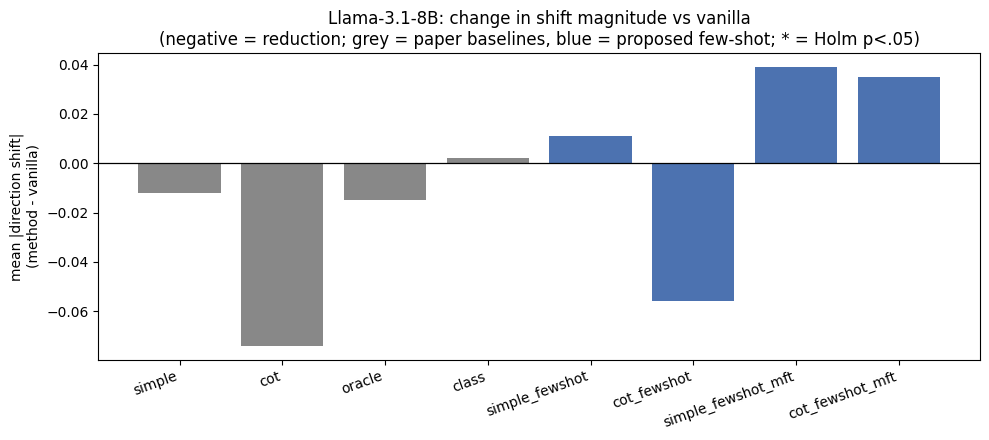

In [6]:
# Visual: difference in |direction shift| vs vanilla (negative = reduces the shift).
methods = [m for m in METHOD_ORDER if m != 'vanilla']
sub = rq2b.set_index('method').loc[methods]
colors = ['#888888' if m in BASELINES else '#4c72b0' for m in methods]

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(range(len(methods)), sub['diff (method - vanilla)'], color=colors)
for xi, (d, sig) in enumerate(zip(sub['diff (method - vanilla)'], sub['reduces shift?'])):
    if sig == 'yes':
        ax.text(xi, d - 0.004, '*', ha='center', va='top', fontsize=14)
ax.axhline(0, color='black', lw=0.9)
ax.set_xticks(range(len(methods)))
ax.set_xticklabels(methods, rotation=20, ha='right')
ax.set_ylabel('mean |direction shift|\n(method - vanilla)')
ax.set_title('Llama-3.1-8B: change in shift magnitude vs vanilla\n'
             '(negative = reduction; grey = paper baselines, blue = proposed few-shot; '
             '* = Holm p<.05)')
fig.tight_layout(); plt.show()

### Few-shot vs zero-shot counterpart

A second, more targeted contrast: does adding the dynamically selected exemplars
help *relative to the zero-shot strategy it extends*? We pair each few-shot variant
with its counterpart (`simple_fewshot`/`simple_fewshot_mft` vs `simple`,
`cot_fewshot`/`cot_fewshot_mft` vs `cot`) on shared articles.

In [7]:
pairs = [('simple_fewshot', 'simple'), ('simple_fewshot_mft', 'simple'),
         ('cot_fewshot', 'cot'),       ('cot_fewshot_mft', 'cot')]
out = []
for method, base in pairs:
    paired = wide[[base, method]].dropna()
    _, p = wilcoxon(paired[method], paired[base])
    out.append({
        'method': method, 'baseline': base, 'n_articles': len(paired),
        'mean_abs_baseline': round(float(paired[base].mean()), 3),
        'mean_abs_method':   round(float(paired[method].mean()), 3),
        'diff (method - baseline)': round(float(paired[method].mean()
                                                 - paired[base].mean()), 3),
        'wilcoxon_p': p,
    })
ctr = pd.DataFrame(out)
ctr['p_holm'] = multipletests(ctr['wilcoxon_p'], method='holm')[1].round(4)
ctr['wilcoxon_p'] = ctr['wilcoxon_p'].round(4)
ctr

,method,baseline,n_articles,mean_abs_baseline,mean_abs_method,diff (method - baseline),wilcoxon_p,p_holm
0,simple_fewshot,simple,132,0.493,0.509,0.015,0.9964,0.9964
1,simple_fewshot_mft,simple,138,0.490,0.522,0.032,0.3470,0.9686
2,cot_fewshot,cot,49,0.407,0.479,0.072,0.3229,0.9686
3,cot_fewshot_mft,cot,60,0.433,0.607,0.174,0.0050,0.0201


### RQ2b — what the numbers say

**No strategy reduces the stance shift.** Against `vanilla`, none of the 8 contrasts
survives Holm correction. The best candidate is `cot_fewshot`
(−0.056, uncorrected p = .050), which is suggestive but does not survive correction
(Holm p = .40); the remaining few-shot variants are directionally *worse* than
vanilla (+0.01 to +0.04, all n.s.). The paper's own moral-aware baselines
(`simple`, `cot`, `oracle`, `class`) are equally flat on this model.

Against their zero-shot counterparts, the few-shot variants add nothing:
three of four contrasts are non-significant, and `cot_fewshot_mft` is significantly
**worse** than plain `cot` (+0.174, Holm p = .02) — prepending exemplars plus MFT
dimension constraints appears to amplify the shift rather than dampen it.

**Answer: no.** On Llama-3.1-8B, neither the paper's moral-aware strategies nor our
proposed few-shot strategies reliably reduce the political stance shift — consistent
with the cross-model RQ2b finding in the main notebook.

*Caveats:* single generation per cell (no seed replicates), incomplete article grid
(n = 19–153 per contrast), and a 4-bit quantized model — all of which add noise, so
small true effects could be missed; but the consistent null across 12 contrasts makes
a large hidden effect unlikely.

## Conclusion

- **RQ2a (8B): yes.** Llama-3.1-8B shifts political stance with the same asymmetric
  regression-to-center signature as the three larger models — left articles pulled
  rightward (+0.35), center articles polarized (+0.19) — slightly stronger than at
  larger scale.
- **RQ2b (8B): no.** None of the eight prompting strategies (paper baselines or our
  dynamic few-shot variants) significantly reduces the shift relative to `vanilla`
  after Holm correction, and `cot_fewshot_mft` significantly *increases* it relative
  to `cot`.

Together with the main notebook: the stance shift is robust across model scale, and
prompting-level interventions — zero-shot or few-shot, moral-aware or not — do not
correct it.